# Quantifying behaviour trial-by-trial

In [2]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

import pyaldata as pyal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import r2_score, make_scorer

from tqdm import tqdm

import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.dsp as dsp

import pickle



In [3]:
handler = decode.DecodingDataHandler(
    data_dir='/data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [5]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end= 399)
# targets = df.values_Sol_direction.values.tolist()

Dropped 11 of 333 rows (3.30%).


In [49]:
bhv_fields = [
            "left_ankle",
            "left_elbow",
            "left_foot",
            "left_knee",
            "left_paw",
            "left_shoulder",
            "left_wrist",
            "right_ankle",
            "right_elbow",
            "right_foot",
            "right_knee",
            "right_paw",
            "right_shoulder",
            "right_wrist",
        ]
trial = 210
perturb_td = dt.add_bhv(perturb_td, bhv_fields=bhv_fields)
signal_ = perturb_td.bhv.values[trial][:, np.arange(2, 2*len(bhv_fields), step=3)]

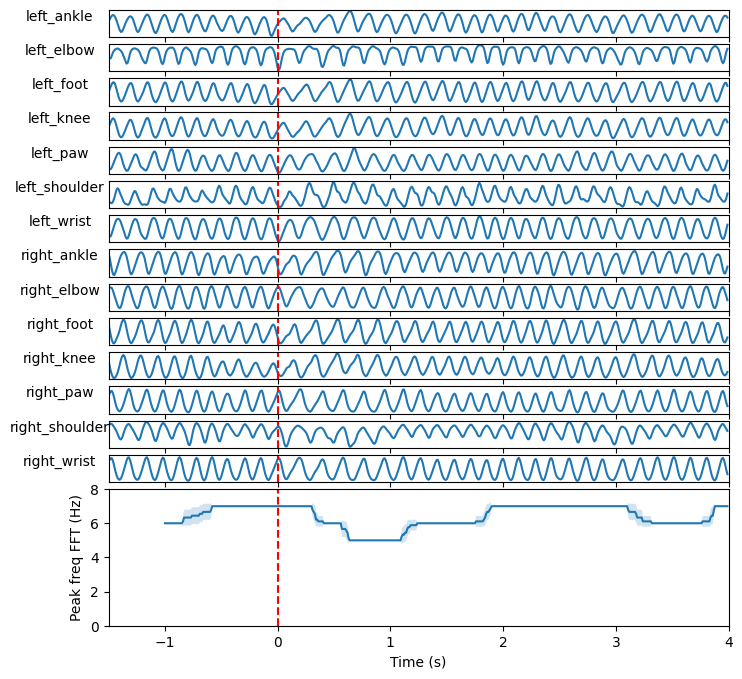

In [76]:
bhv_fields = [
            "left_ankle",
            "left_elbow",
            "left_foot",
            "left_knee",
            "left_paw",
            "left_shoulder",
            "left_wrist",
            "right_ankle",
            "right_elbow",
            "right_foot",
            "right_knee",
            "right_paw",
            "right_shoulder",
            "right_wrist",
        ]
trial = 50
perturb_td = dt.add_bhv(perturb_td, bhv_fields=bhv_fields)
signal_ = perturb_td.bhv.values[trial][:, np.arange(2, 2*len(bhv_fields), step=3)]
fft_window_length = 100
peak_freq = []
for i in np.arange(start=fft_window_length, stop=600):
    freqs, psd = scipy.signal.welch(
        signal_[i-fft_window_length:i, :], fs=100, nperseg=fft_window_length, axis=0
        )
    peak_freq.append(freqs[np.argmax(psd, axis=0)])
peak_freq = np.array(peak_freq)

# with vizutils.apply_plot_style('notebook'):
fig, axs = plt.subplots(len(bhv_fields)+1, 1, figsize=(8, 8), 
                        gridspec_kw={'height_ratios': [1]*len(bhv_fields) + [5]},
                        sharex='all')
for idx, ax in enumerate(axs[:-1]):
    ax.plot((np.arange(start=0, stop=600) / 100)-2, perturb_td[f"{bhv_fields[idx]}"].values[trial][:, 2])
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_ylabel(bhv_fields[idx], rotation=0, labelpad=35, va='center')
    ax.yaxis.set_label_position("left")
    ax.set_yticks([]) 


vizutils.shaded_errorbar(axs[-1], (np.arange(start=fft_window_length, stop=600) / 100)-2, peak_freq)

axs[-1].axvline(0, color='red', linestyle='dashed')
ax.set_xlim(-1.5, 4)
axs[-1].set_ylabel('Peak freq FFT (Hz)')
axs[-1].set_xlabel('Time (s)')
axs[-1].set_ylim(0, 8)

plt.show()

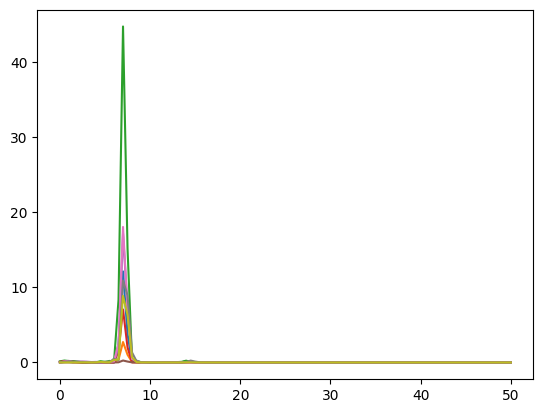

In [55]:
freqs, psd = scipy.signal.welch(signal_[:200, :], fs=100, axis=0, nperseg=200, noverlap=40)

fig, ax = plt.subplots()
ax.plot(freqs, psd)
plt.show()

In [60]:
psd.max(0)

array([12.12373818,  2.72393829, 44.7372542 ,  7.05717642, 17.17841615,
        0.26234381, 18.04380031, 10.91511889,  8.86221745])

(<matplotlib.lines.Line2D at 0x7455d7899590>,
 <matplotlib.collections.FillBetweenPolyCollection at 0x7455d78996d0>)

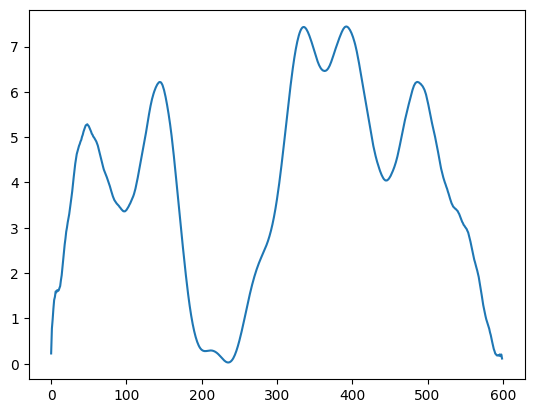

In [45]:
power = dsp.get_power_in_freq_range(signal_, fs=100, freqs=(6, 8), order=4)
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, power)

(<matplotlib.lines.Line2D at 0x7455d6013b10>,
 <matplotlib.collections.FillBetweenPolyCollection at 0x7455d6013c50>)

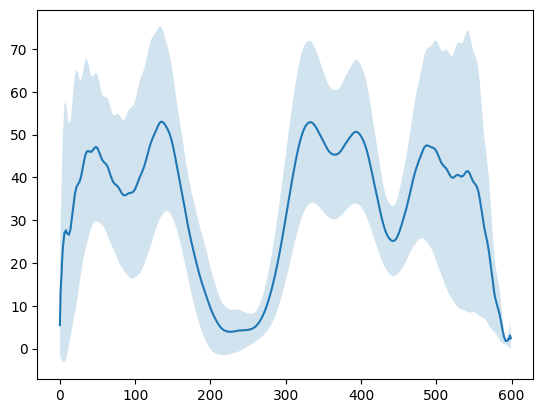

In [75]:
bhv_fields = [
            "left_ankle",
            "left_elbow",
            "left_foot",
            "left_knee",
            "left_paw",
            "left_shoulder",
            "left_wrist",
            "right_ankle",
            "right_elbow",
            "right_foot",
            "right_knee",
            "right_paw",
            "right_shoulder",
            "right_wrist",
        ]
trial = 210
perturb_td = dt.add_bhv(perturb_td, bhv_fields=bhv_fields)
signal_ = perturb_td.bhv.values[trial][:, np.arange(2, 2*len(bhv_fields), step=3)]
freqs, psd = scipy.signal.welch(signal_[:200, :], fs=100, axis=0, nperseg=200)
max_power_keypoint = np.argsort(psd.max(0))[::-1]
max_power_keypoint = max_power_keypoint[:3]

max_freq = freqs[psd.mean(-1).argmax()]
power = dsp.get_power_in_freq_range(signal_[:, max_power_keypoint], fs=100, freqs=(max_freq-1, max_freq+1), order=4)
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, power)
# ax.plot(power)

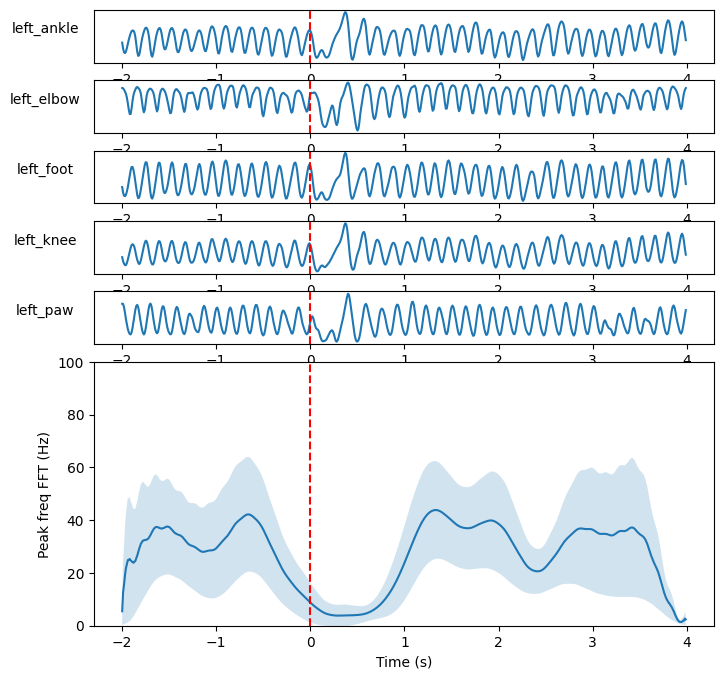

In [88]:
bhv_fields = [
            "left_ankle",
            "left_elbow",
            "left_foot",
            "left_knee",
            "left_paw",
            "left_shoulder",
            "left_wrist",
            "right_ankle",
            "right_elbow",
            "right_foot",
            "right_knee",
            "right_paw",
            "right_shoulder",
            "right_wrist",
        ]
trial = 210
max_keys = 5
perturb_td = dt.add_bhv(perturb_td, bhv_fields=bhv_fields)
signal_ = perturb_td.bhv.values[trial][:, np.arange(2, 2*len(bhv_fields), step=3)]
freqs, psd = scipy.signal.welch(signal_[:200, :], fs=100, axis=0, nperseg=200)
max_power_keypoint = np.argsort(psd.max(0))[::-1]
max_power_keypoint = max_power_keypoint[:max_keys]

# with vizutils.apply_plot_style('notebook'):
fig, axs = plt.subplots(len(max_power_keypoint)+1, 1, figsize=(8, 8), 
                        gridspec_kw={'height_ratios': [1]*len(max_power_keypoint) + [5]},
                        sharex='none')
for idx, ax in enumerate(axs[:-1]):
    ax.plot((np.arange(start=0, stop=600) / 100)-2, perturb_td[f"{bhv_fields[idx]}"].values[trial][:, 2])
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_ylabel(bhv_fields[idx], rotation=0, labelpad=35, va='center')
    ax.yaxis.set_label_position("left")
    ax.set_yticks([]) 


max_freq = freqs[psd.mean(-1).argmax()]
power = dsp.get_power_in_freq_range(signal_[:, max_power_keypoint], fs=100, freqs=(max_freq-1, max_freq+1), order=4)
vizutils.shaded_errorbar(axs[-1], (np.arange(start=0, stop=600) / 100)-2, power)

axs[-1].axvline(0, color='red', linestyle='dashed')
# ax.set_xlim(-1.5, 4)
axs[-1].set_ylabel('Peak freq FFT (Hz)')
axs[-1].set_xlabel('Time (s)')
axs[-1].set_ylim(0, 100)

plt.show()

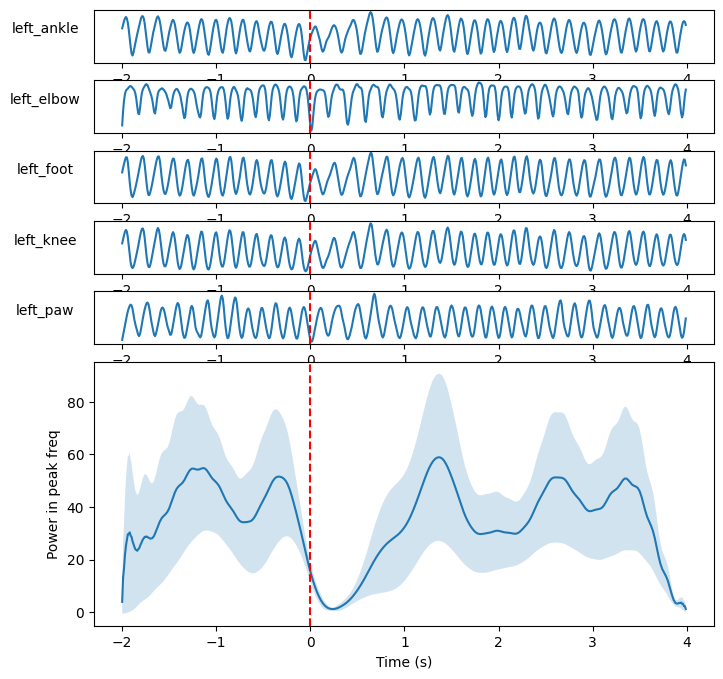

In [93]:
bhv_fields = [
            "left_ankle",
            "left_elbow",
            "left_foot",
            "left_knee",
            "left_paw",
            "left_shoulder",
            "left_wrist",
            "right_ankle",
            "right_elbow",
            "right_foot",
            "right_knee",
            "right_paw",
            "right_shoulder",
            "right_wrist",
        ]
trial = 50
max_keys = 5
times = (np.arange(start=0, stop=600) / 100)-2
perturb_td = dt.add_bhv(perturb_td, bhv_fields=bhv_fields)
signal_ = perturb_td.bhv.values[trial][:, np.arange(2, 2*len(bhv_fields), step=3)]
freqs, psd = scipy.signal.welch(signal_[:200, :], fs=100, axis=0, nperseg=200)
max_power_keypoint = np.argsort(psd.max(0))[::-1]
max_power_keypoint = max_power_keypoint[:max_keys]

# with vizutils.apply_plot_style('notebook'):
fig, axs = plt.subplots(len(max_power_keypoint)+1, 1, figsize=(8, 8), 
                        gridspec_kw={'height_ratios': [1]*len(max_power_keypoint) + [5]},
                        sharex='none')
for idx, ax in enumerate(axs[:-1]):
    ax.plot(times, perturb_td[f"{bhv_fields[idx]}"].values[trial][:, 2])
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_ylabel(bhv_fields[idx], rotation=0, labelpad=35, va='center')
    ax.yaxis.set_label_position("left")
    ax.set_yticks([]) 


max_freq = freqs[psd.mean(-1).argmax()]
power = dsp.get_power_in_freq_range(signal_[:, max_power_keypoint], fs=100, freqs=(max_freq-1, max_freq+1), order=4)
vizutils.shaded_errorbar(axs[-1], times, power)

axs[-1].axvline(0, color='red', linestyle='dashed')
# ax.set_xlim(-1.5, 4)
axs[-1].set_ylabel('Power in peak freq')
axs[-1].set_xlabel('Time (s)')
# axs[-1].set_ylim(0, 100)

plt.show()

# Rotative behaviour

In [72]:
df = pd.read_csv('behaviour.csv')
df = df.rename(columns={"Unnamed: 0": "Animal"})
df_t = df.set_index("Animal").T

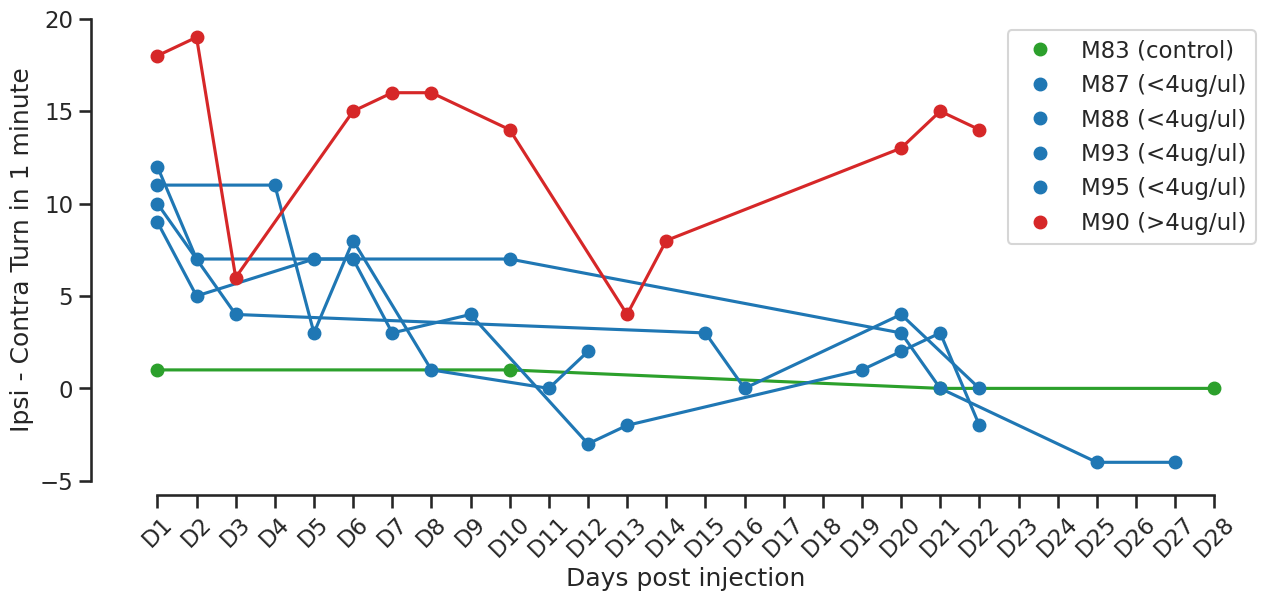

In [108]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots(figsize=(15, 6))

    for animal in ['M83', 'M87', 'M88', 'M93', 'M95', 'M90']:#df_t.columns:
        nanmask = ~np.isnan(df_t[animal].values)

        # Extract the colour that Matplotlib assigned
        if animal == 'M83':
            label = 'M83 (control)'
            color = 'tab:green'
        elif animal == 'M90':
            label = 'M90 (>4ug/ul)'
            color='tab:red'
        else:
            label=f"{animal} (<4ug/ul)"
            color="tab:blue"
        line = ax.errorbar(df_t.index, df_t[animal].values, fmt='o', label=label, color=color)
        line_color = line[0].get_color()

        ax.plot(df_t.index[nanmask], df_t[animal].values[nanmask], color=line_color)
    ax.legend(loc='upper right')
    ax.set_ylabel('Ipsi - Contra Turn in 1 minute')
    ax.set_xlabel('Days post injection')
    ax.set_ylim(-5, 20)
plt.xticks(rotation=45)
plt.show()